In [16]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
lick_color, attn_color='tab:orange', 'tab:blue'
sig_color='black'

start_rgb = (0.0, 1, 0.7) # low reward
end_rgb = (0.0, 0.2, 0.2) # high reward
cmap = LinearSegmentedColormap.from_list('custom_cmap', [start_rgb, end_rgb])



food reard list:  ['0', '111', '222', '333', '444', '555', '666', '777', '888']


/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


ycstore/seed_0_varyreward npv3_epoch_0


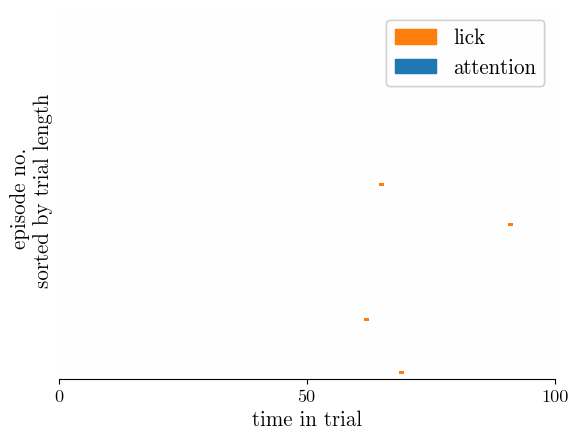

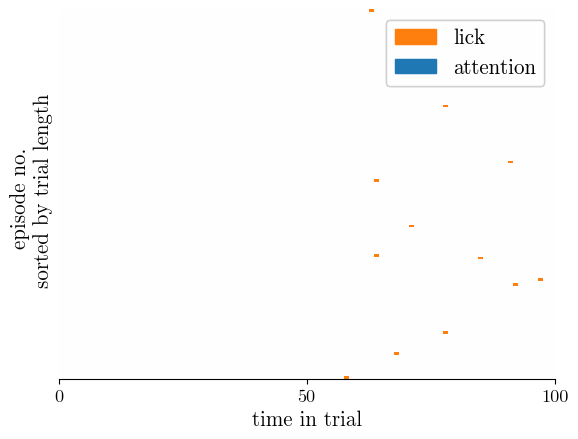

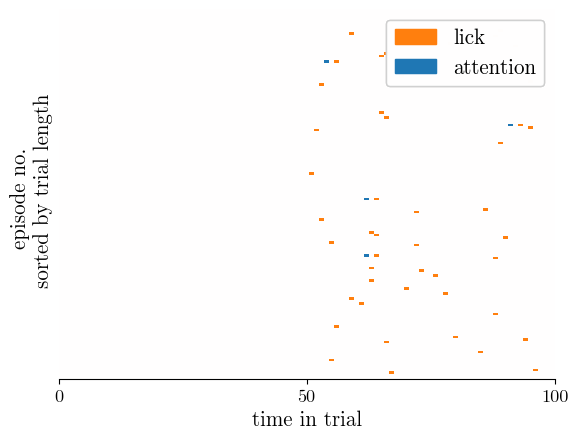

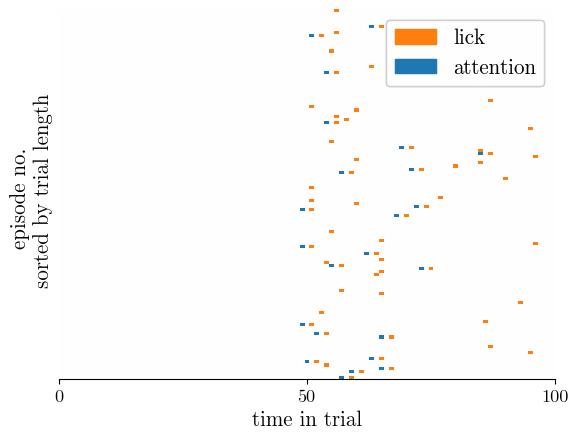

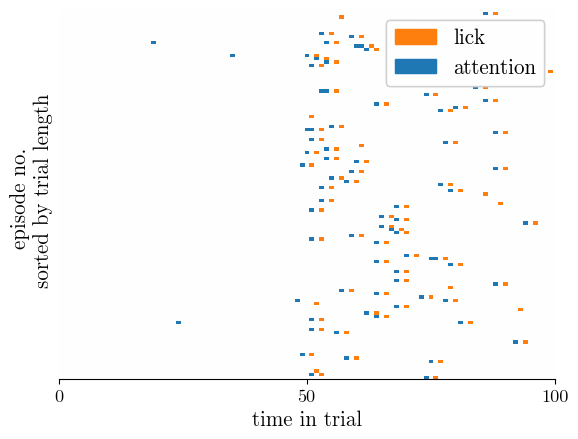

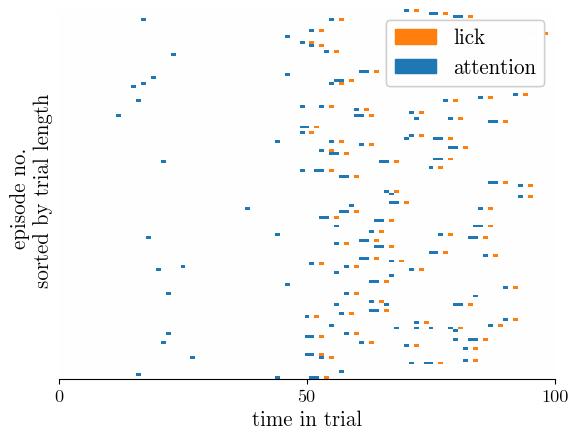

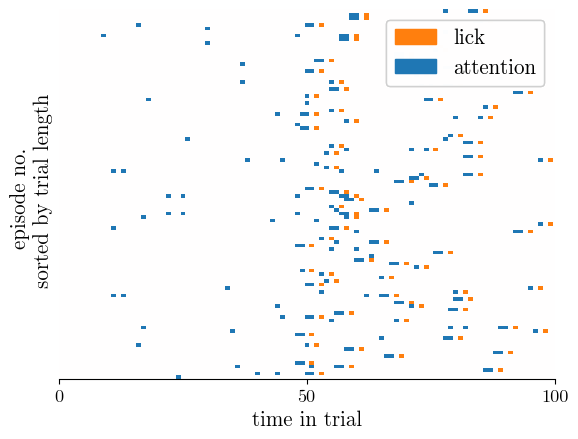

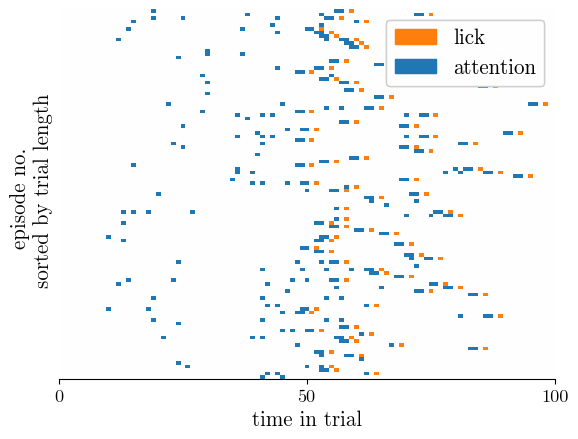

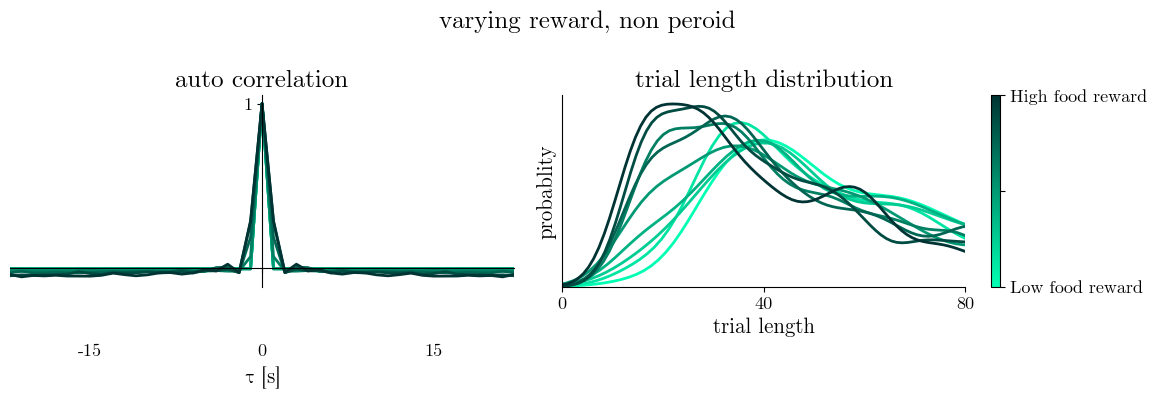

ycstore/seed_0_varyreward npv3_epoch_1


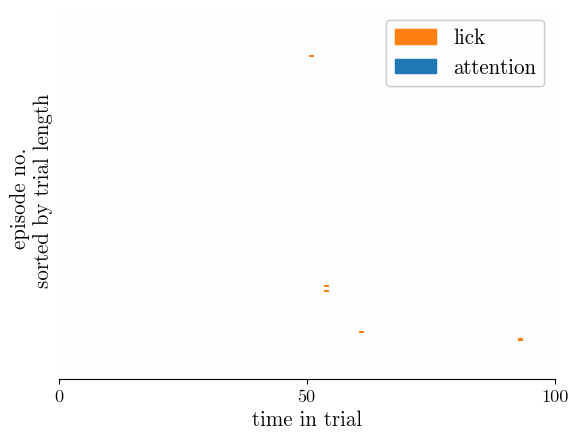

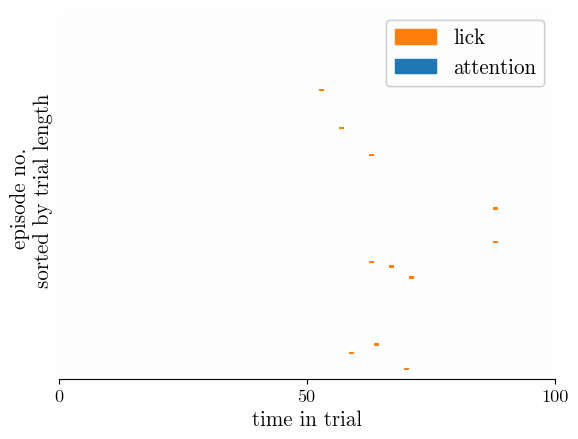

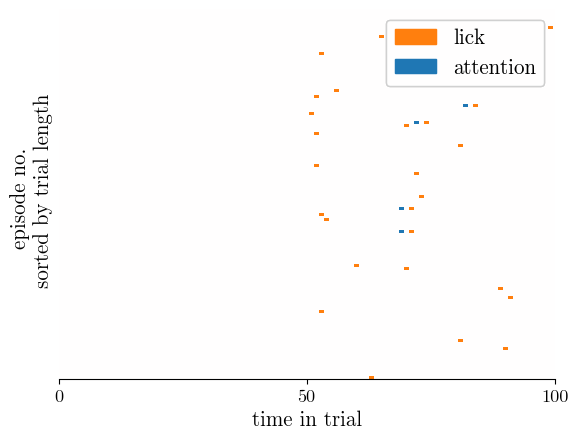

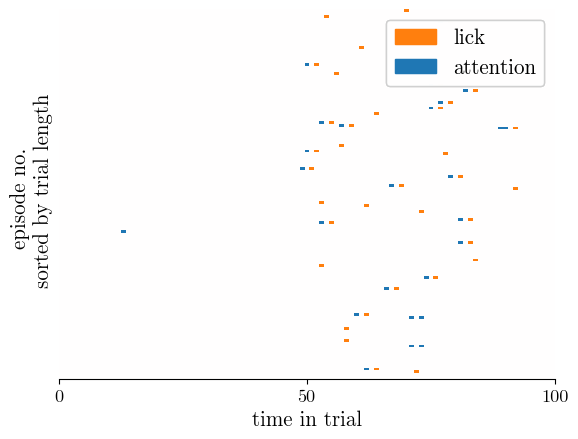

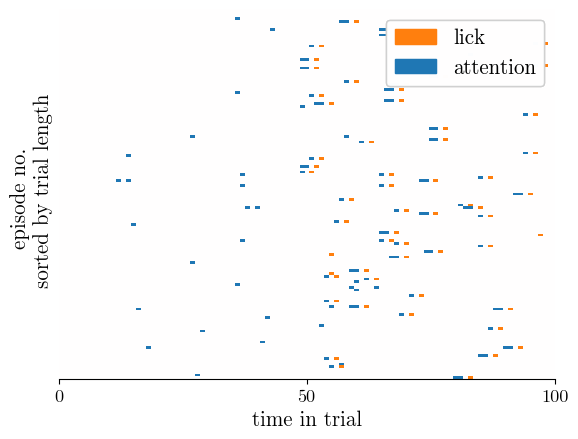

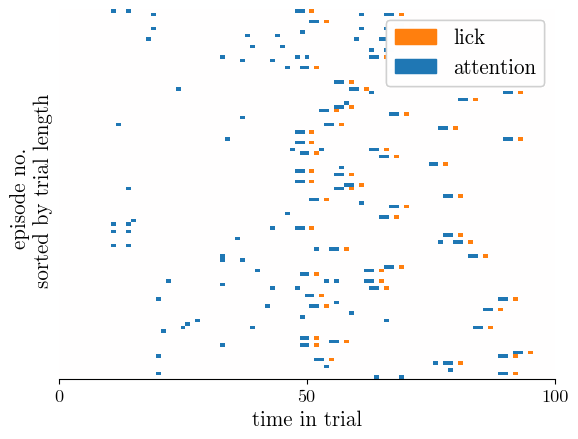

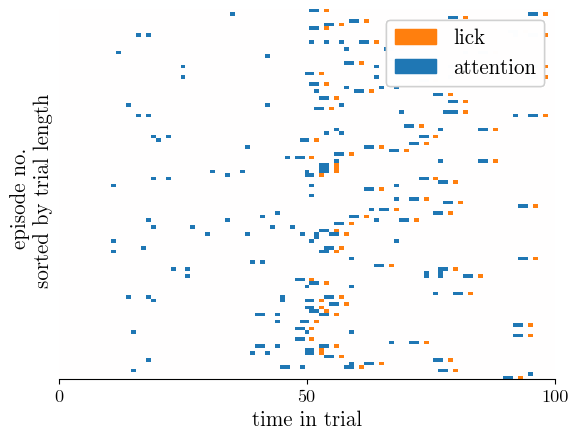

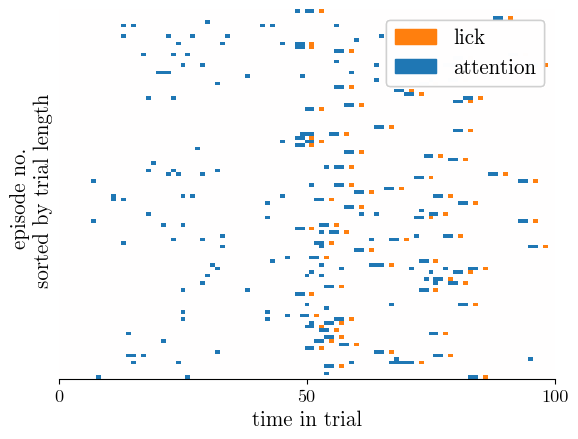

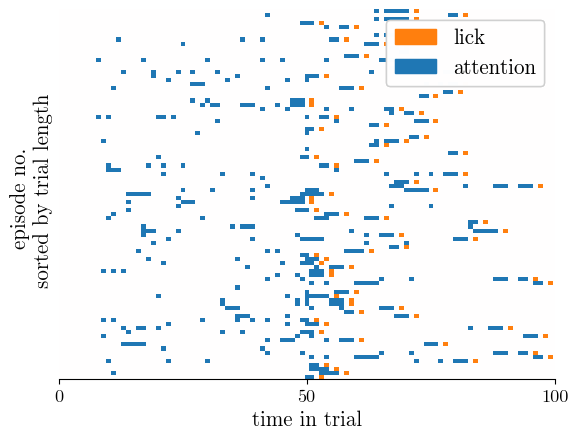

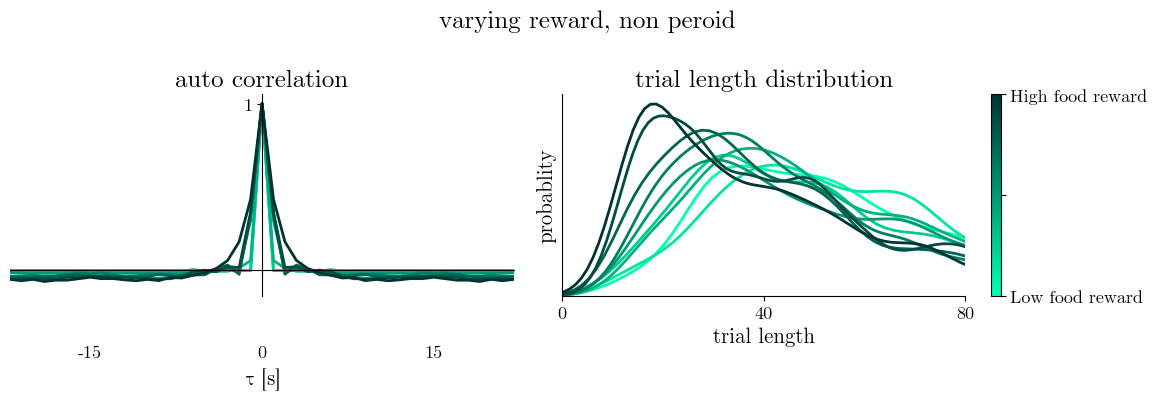

ycstore/seed_0_varyreward npv3_epoch_2


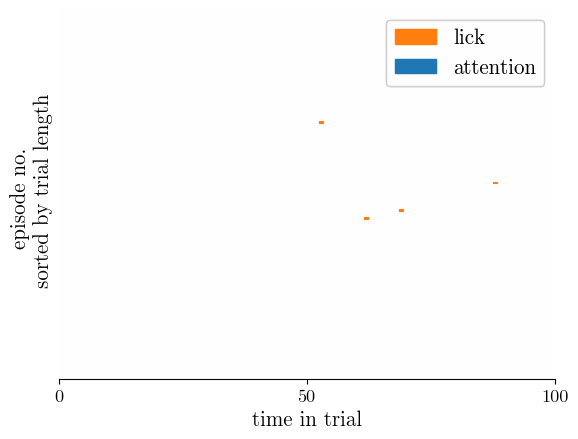

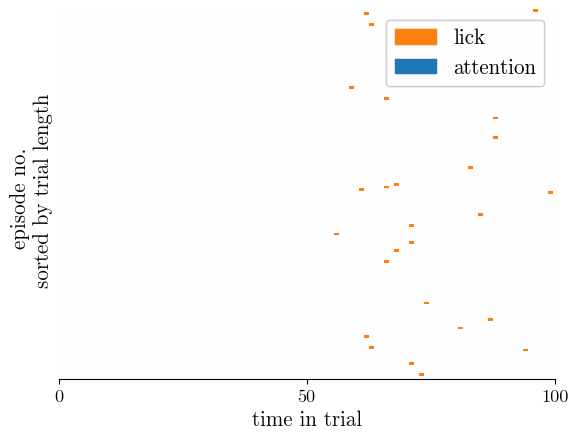

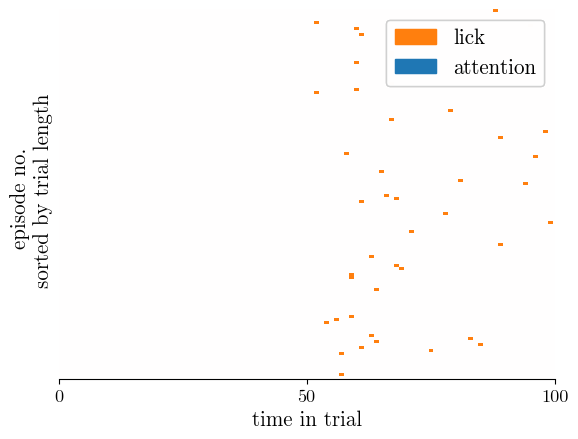

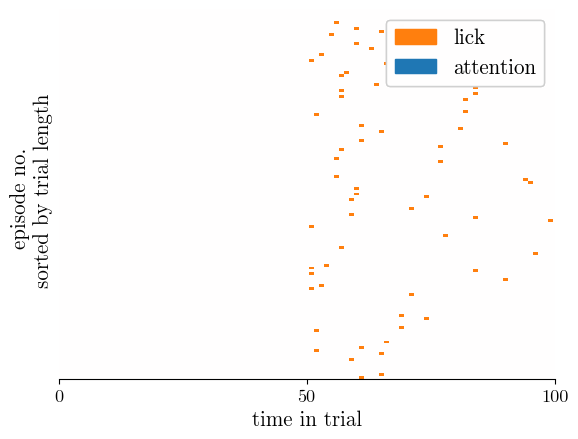

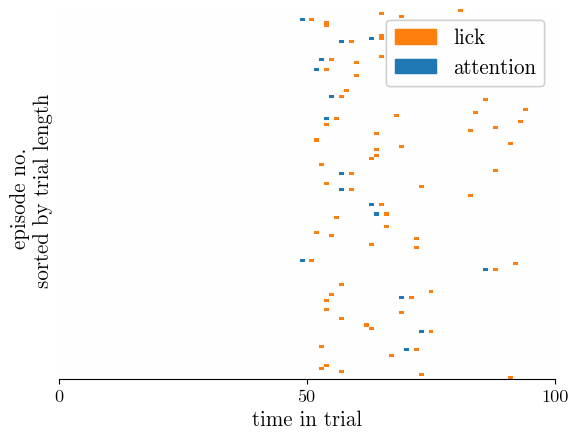

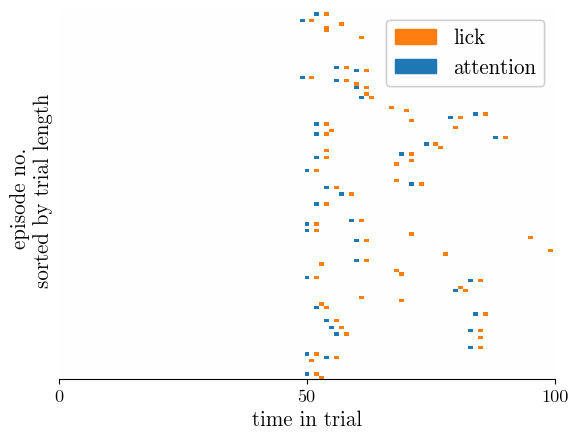

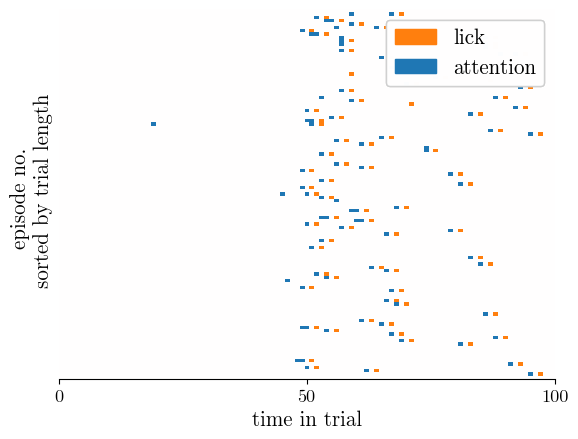

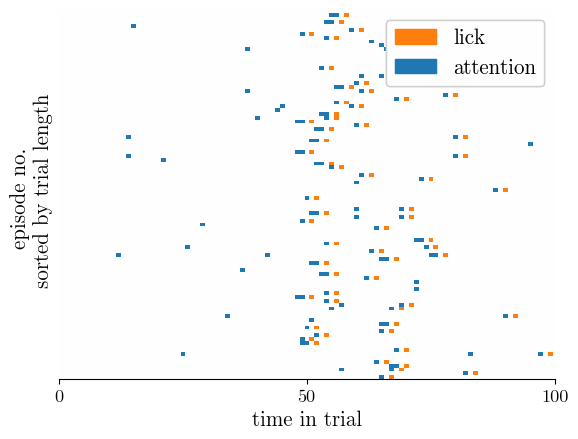

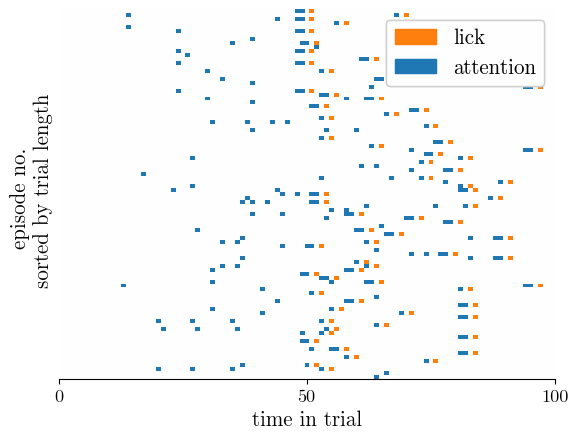

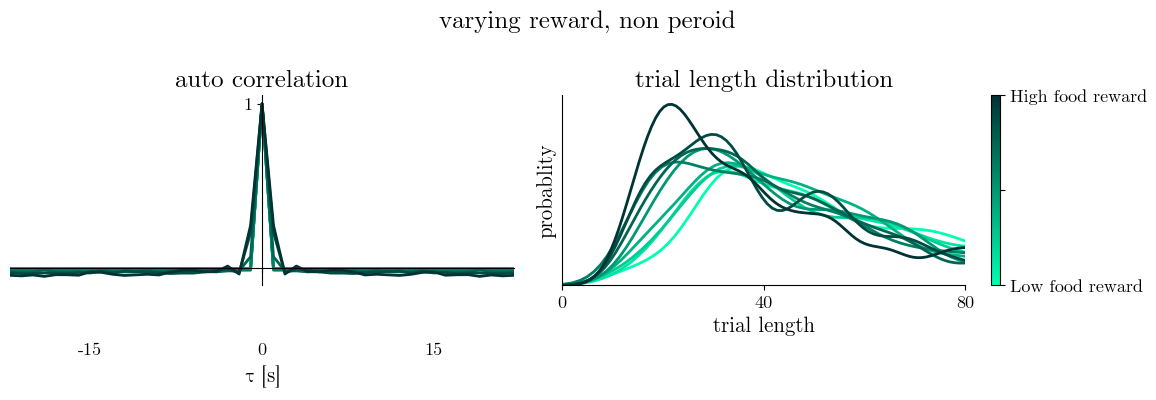

ycstore/seed_0_varyreward npv3_epoch_3


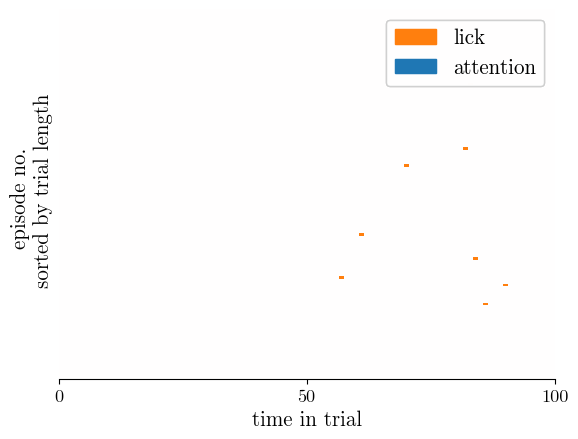

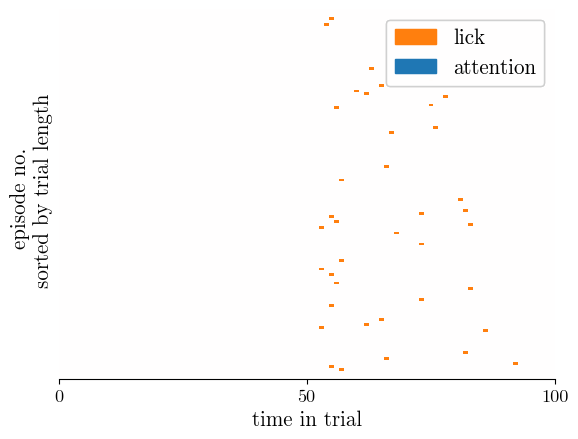

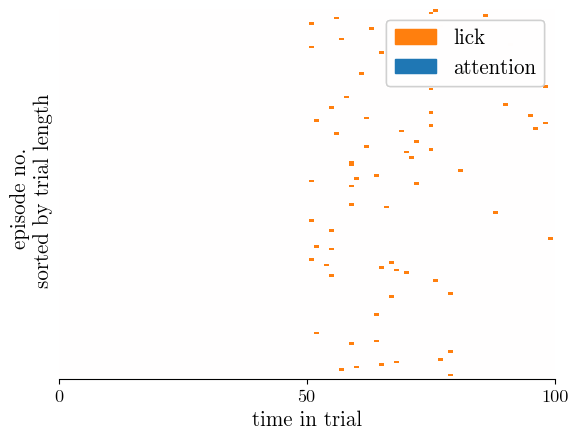

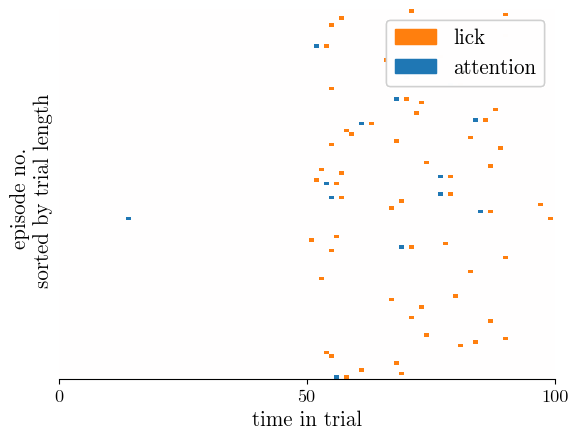

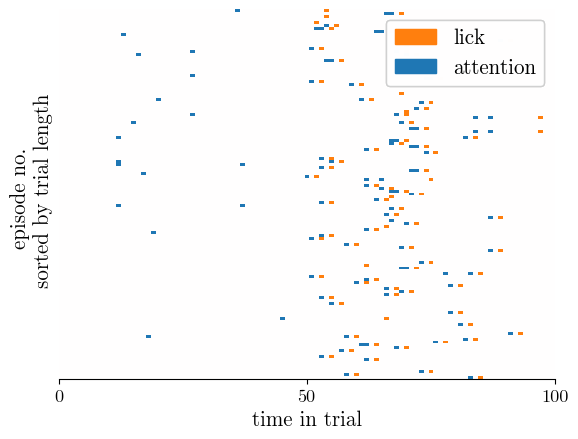

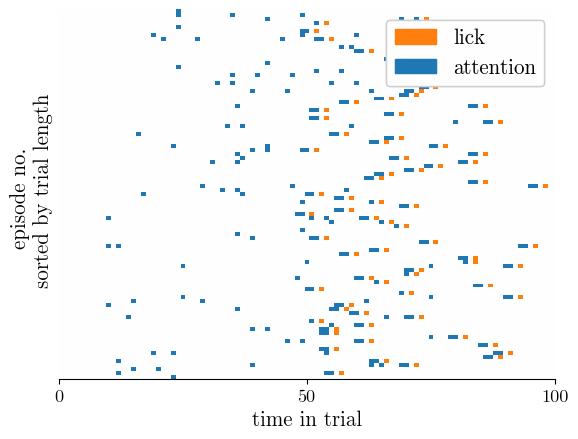

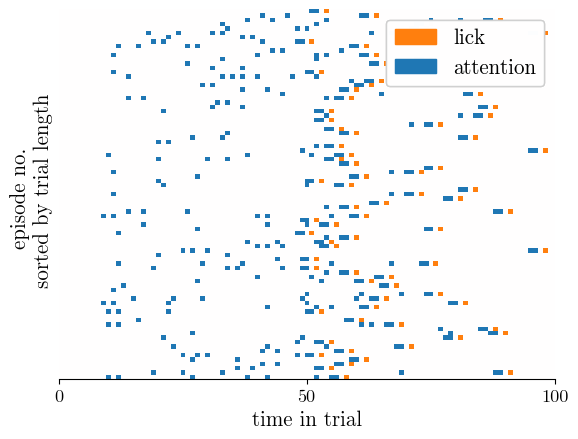

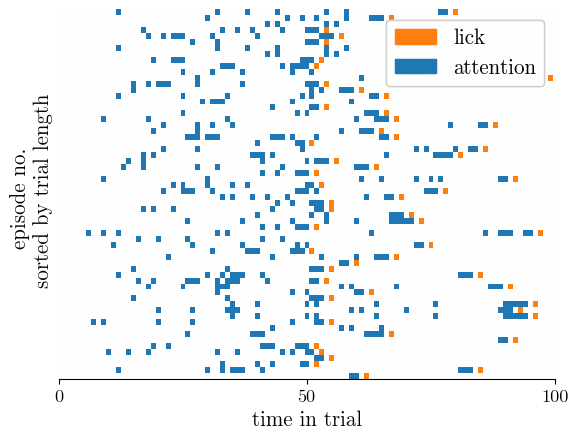

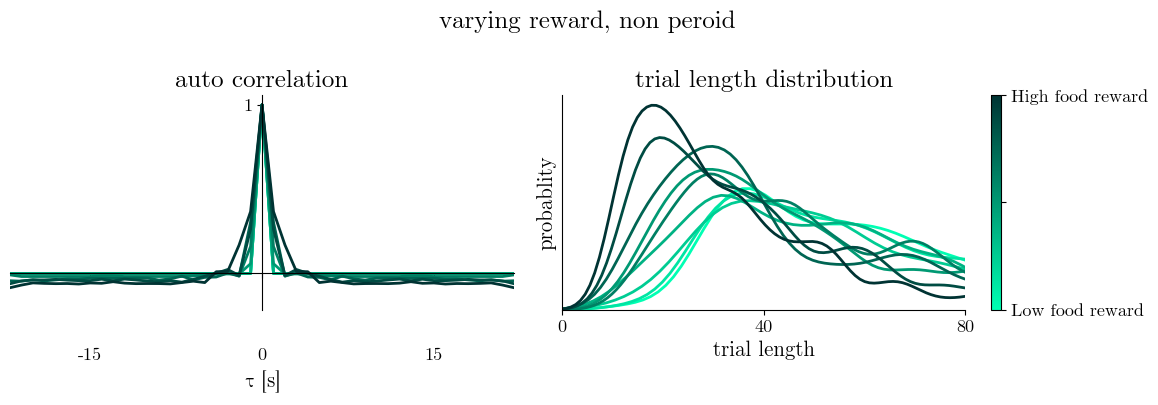

ycstore/seed_0_varyreward npv3_epoch_4


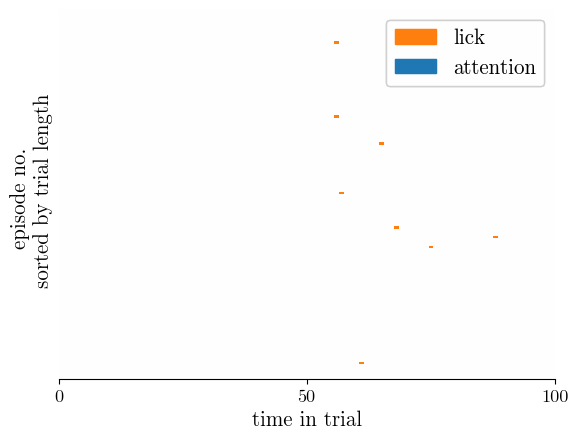

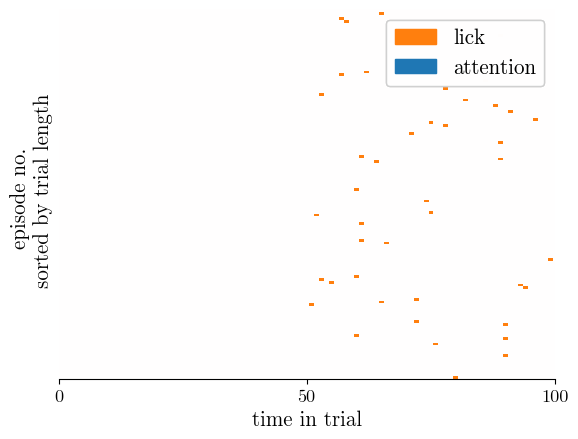

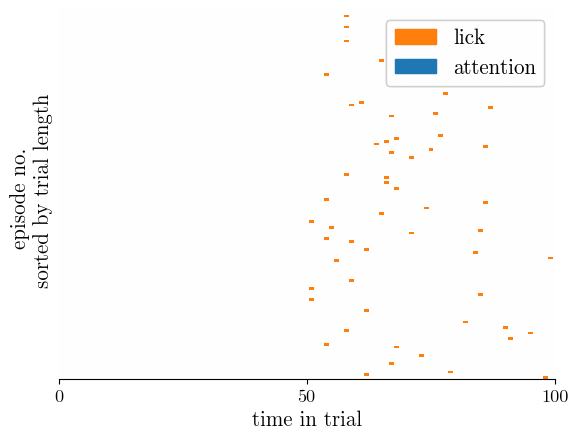

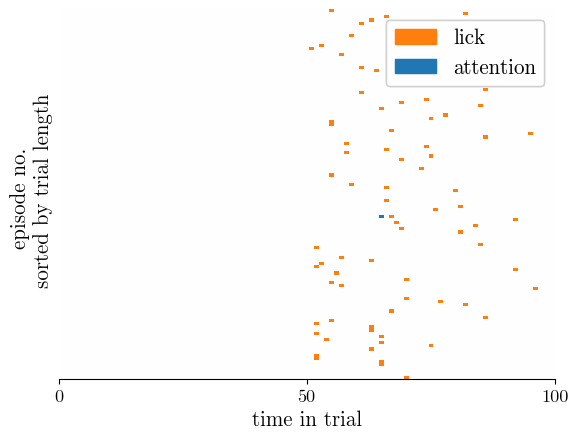

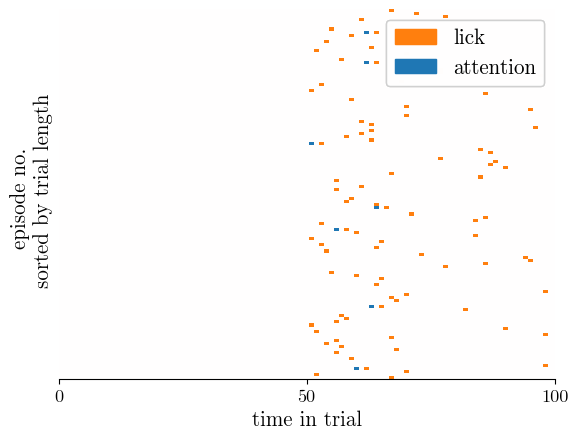

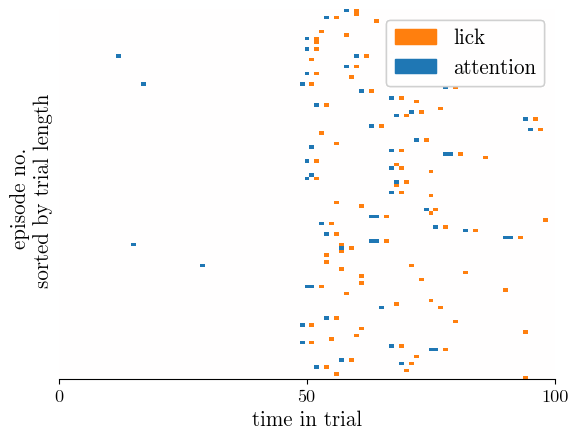

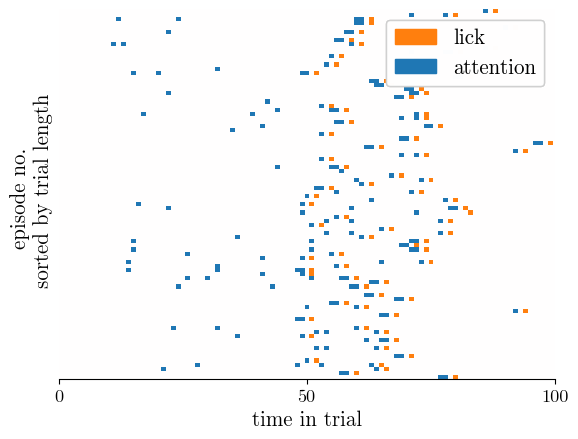

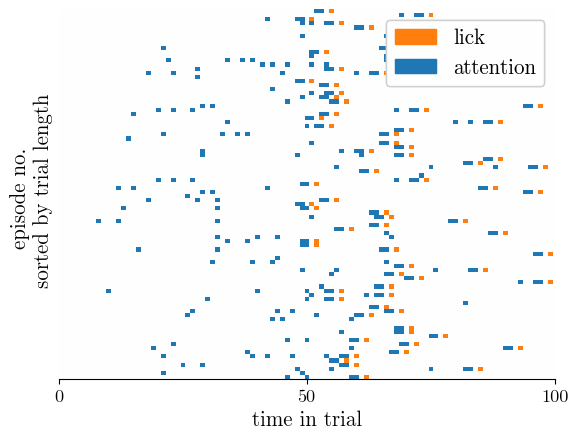

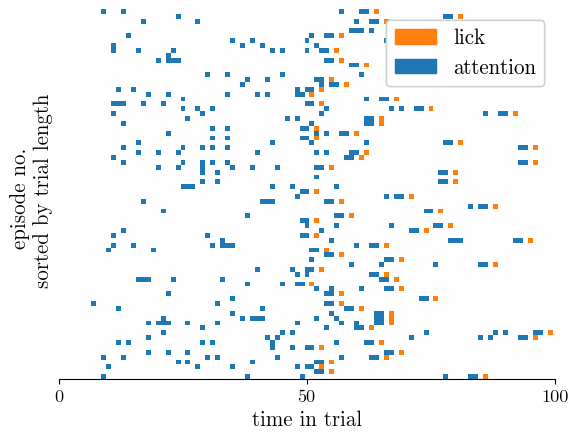

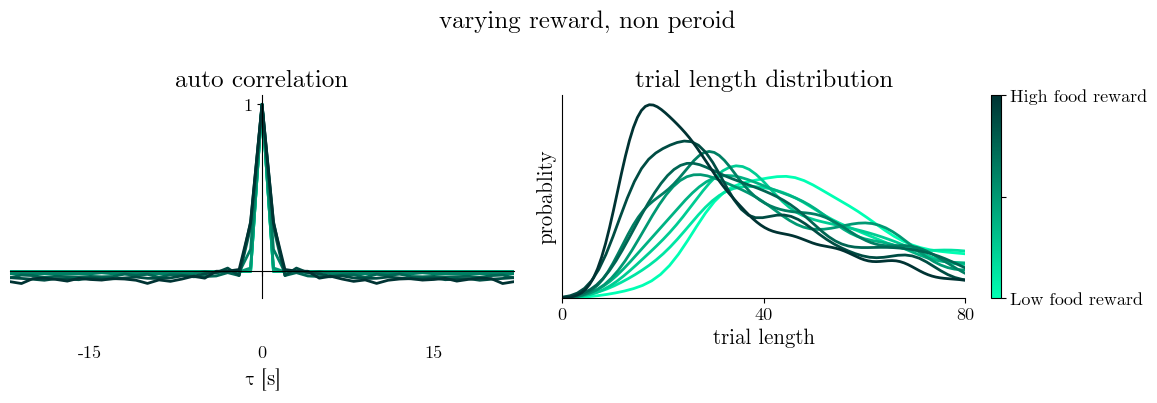

In [18]:
modelname = 'varyreward npv3'
# training hyper params
epoch_size = 33333*5

n_epoch = 5
n_seed = 1
attcost=-1
facost=-50
p1p2 = np.array([.6, .7])
vmin, vmax = 0, 888
food_reward_list = np.linspace(vmin, vmax, 9)
print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])
env_param = [0, None, attcost, .25, facost, 0, 0]
seed=0
thismodel = f'seed_{seed}_{modelname}'

for seed in range(n_seed):
    # set seed
    np.random.seed(seed)
    task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                                'food_reward': env_param[1],
                                'attention_cost_coeff': env_param[2],
                                'attention_cost_temp': env_param[3],
                                'penalty_cost': env_param[4],
                                'iti_cost': env_param[5],
                                'time_in_game_reward': env_param[6]}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    # set p1 p2
    task.obs_certainity_possible = p1p2
    model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs/{modelname}",)
    # train
    for i in range(n_epoch):
        model.learn(total_timesteps=epoch_size,
                    tb_log_name=thismodel,
                    reset_num_timesteps=False,
                    )
        model.save(f'ycstore/{thismodel}_epoch_{i}')
        print(f'ycstore/{thismodel}_epoch_{i}')

        # eval
        # collect trial data
        no_episodes=3333
        def eval_wrapper(a):
            episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                    num_steps=100000, deterministic=True)
            return episode

        with multiprocess.Pool(processes=8) as pool:
            all_episode_data = pool.map(eval_wrapper, range(no_episodes))

        
        all_reward_res={} # k: v = foodreward idx: this food reward res
        for r in range(len(food_reward_list)):
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
            all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len


        for episode in all_episode_data[:]:
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
            att_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
        
            if episode['actions'][-1][0] == 1:
                lick_time_list.append(len(episode['states']))
            else:
                lick_time_list.append(None)
            trial_len.append(len(episode['actions']))


        # heatmap trial indicator (att and lick) new, select len
        minlen, maxlen = 50, 100
        for food_reward_idx in (all_reward_res.keys()):
            attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
                food_reward_idx]
            trial_len = np.array(trial_len)
            valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
            grid = np.zeros((len(valid_ind), max(trial_len)+2))

            # att
            plot_data = [att_time_list[i] for i in valid_ind]
            for i, arr in enumerate(plot_data):
                grid[i, arr] = -1

            # lick
            plot_data = [lick_time_list[i] for i in valid_ind]
            for i, arr in enumerate(plot_data):
                if arr:
                    grid[i, arr] = 1
            grid=grid[:,1:] # remove the iti state
            if np.sum(grid) == 0:
                continue
            plt.figure()

            colors = [attn_color, 'white', lick_color]
            stops = [0.0, 0.5, 1.0]
            attnlickcmap = LinearSegmentedColormap.from_list(
                'custom_cmap', list(zip(stops, colors)))

            c = plt.imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                        aspect='auto', interpolation='none')

            plt.xticks([0, 50, 100])
            plt.xlim(0, 100)
            plt.yticks([])
            ax = plt.gca()
            ax.spines['left'].set_visible(False)
            plt.xlabel('time in trial')
            plt.ylabel('episode no. \n sorted by trial length')
            # plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

            lickdot = Patch(color=lick_color, label='lick')
            attdot = Patch(color=attn_color, label='attention')
            extra_legend = plt.legend(
                handles=[lickdot, attdot], bbox_to_anchor=(1, 1), frameon=True)
            ax.add_artist(extra_legend)
            # quickleg(ax)

            ax.add_artist(extra_legend)

            # quicksave(f'ep indicator {food_reward_idx}', modelname)
            plt.show()




        # autocorr
        from ult import empirical_autocorrelation_new
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        use_reward = np.arange(len(food_reward_list))
        # auto correlation
        for i, food_reward_idx in enumerate(use_reward):
            att_seq_list = []
            for episode in all_episode_data:
                if episode['trial_food_reward_idx'] == food_reward_idx:
                    att_seq_list.append([float(elt[1])
                                        for elt in episode['actions']])
            # Sorting based on increasing trial length
            sorted_list_of_lists = sorted(att_seq_list, key=len)
            # Choosing what range of trial lengths to use. Could modify to be more consistent.
            sequences = sorted_list_of_lists[-555:]
            # autocorr
            autocorr, total_counts = empirical_autocorrelation_new(
                sequences, min_no_samples=0)
            xs = np.arange(0, len(autocorr), 1)
            xs = xs-len(xs)//2
            ax1.plot(xs, autocorr,
                    label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=cmap(np.linspace(0, 1, len(use_reward)))[i])
            # trial len dist
            sns.kdeplot([len(a) for a in att_seq_list],
                        fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(use_reward)))[i])

            ax1.set_xlabel(r'$\tau$ [s]')
            ax1.set_title('auto correlation')
            ax1.set_xlim(-22, 22)
            # ax1.set_ylim(None, 1)
            ax1.set_xticks([-15, 0, 15])
            # ax1.set_yscale('log')
            ax1.set_yticks([1])
            ax1.spines['left'].set_position('zero')
            ax1.spines['bottom'].set_position('zero')
            ax1.tick_params(axis='x', pad=50) 

            ax2.set_xlabel('trial length')
            ax2.set_ylabel('probablity')
            ax2.set_xlim(0, 80)
            ax2.set_xticks([0, 40, 80])
            ax2.set_yticks([])
            ax2.set_title('trial length distribution')

        color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
        ticks = [0, 0.5, 1]
        tick_labels = ['Low food reward', '', 'High food reward']
        color_bar.set_ticks(ticks)
        color_bar.set_ticklabels(tick_labels)


        fig.suptitle('varying reward, non peroid')
        plt.tight_layout()
        # quicksave('autocorr', modelname)
        plt.show()


    notify(f'training {thismodel} finished')
